       amount  transaction_hour  merchant_risk  device_risk   ip_risk  \
0   47.638704               5.0       0.460040     0.850544  0.612999   
1  545.331264               1.0       0.831044     0.912039  0.528633   
2   55.345349               8.0       0.962670     0.682117  0.696648   
3  180.234358              11.0       0.986031     0.951514  0.742730   
4  765.062735              14.0       0.974925     0.978834  0.228919   

   distance_km  velocity_1h  velocity_24h  account_age_days  failed_attempts  \
0     2.253789    -1.028377     -1.639439          0.570816        -1.410637   
1     3.174177    -2.262532     -1.439179          0.180613        -3.243785   
2    -4.288127     0.521658     -0.651694          0.215481         1.875204   
3     0.631351     0.505727     -0.346784          0.452496         2.906251   
4    -2.456547    -4.600772     -0.400178         -2.345139         2.648484   

   international  new_device  is_fraud  
0              1           1         0 

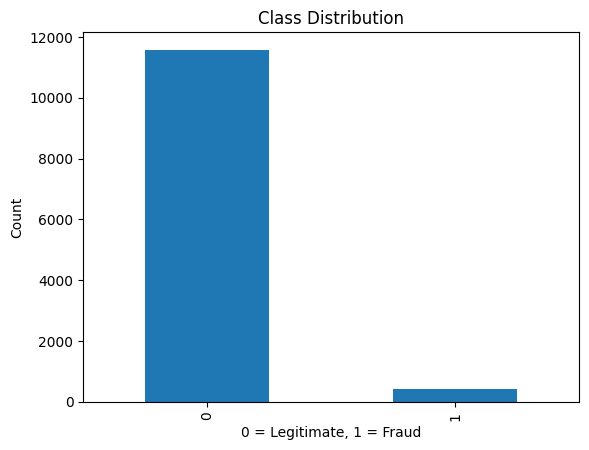

              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      2316
       Fraud       0.34      0.33      0.34        84

    accuracy                           0.95      2400
   macro avg       0.66      0.66      0.66      2400
weighted avg       0.95      0.95      0.95      2400

Accuracy: 0.9541666666666667
Precision: 0.34146341463414637
Recall: 0.3333333333333333
F1: 0.3373493975903614
ROC-AUC: 0.8567316391150588


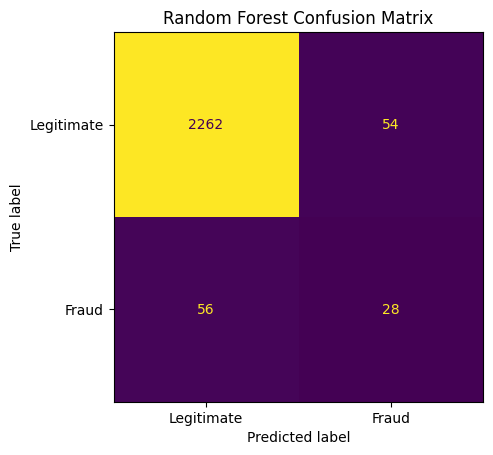

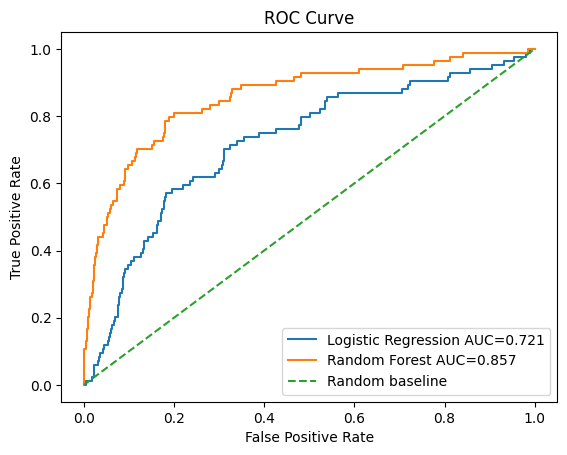

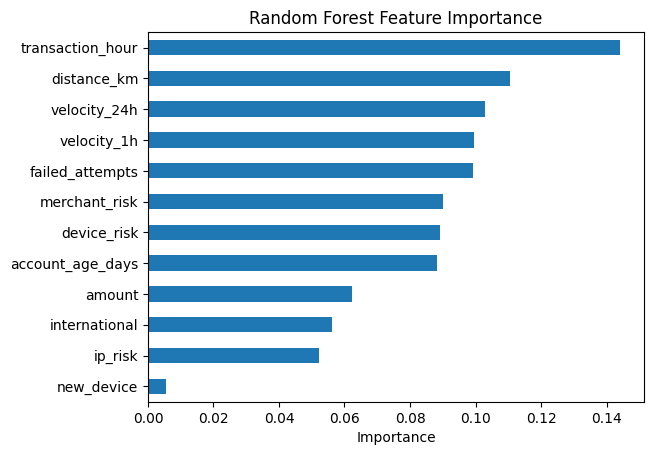

Fraud probability: 0.5683
Prediction: Fraud


In [1]:
# Bank Fraud Detection using Machine Learning
# Glowlogics AI in Python Internship Project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
    accuracy_score
)

# 1. Create reproducible synthetic, imbalanced transaction data
X, y = make_classification(
    n_samples=12000, n_features=12, n_informative=8, n_redundant=2,
    weights=[0.97, 0.03], flip_y=0.01, class_sep=1.1, random_state=42
)

features = [
    "amount","transaction_hour","merchant_risk","device_risk","ip_risk",
    "distance_km","velocity_1h","velocity_24h","account_age_days",
    "failed_attempts","international","new_device"
]
df = pd.DataFrame(X, columns=features)
df["amount"] = np.abs(df["amount"]) * 180 + 20
df["transaction_hour"] = np.mod(np.round((df["transaction_hour"] + 3) * 3), 24)
for c in ["merchant_risk","device_risk","ip_risk"]:
    df[c] = 1 / (1 + np.exp(-df[c]))
df["international"] = (df["international"] > df["international"].median()).astype(int)
df["new_device"] = (df["new_device"] > df["new_device"].median()).astype(int)
df["is_fraud"] = y

print(df.head())
print("Dataset shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())

# 2. Visualize class imbalance
df["is_fraud"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("0 = Legitimate, 1 = Fraud")
plt.ylabel("Count")
plt.show()

# 3. Train/test split
X = df.drop(columns="is_fraud")
y = df["is_fraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 4. Logistic Regression baseline
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
log_model.fit(X_train, y_train)
p_log = log_model.predict_proba(X_test)[:,1]
pred_log = (p_log >= 0.50).astype(int)

# 5. Random Forest main model
rf_model = RandomForestClassifier(
    n_estimators=250, class_weight="balanced_subsample",
    max_depth=12, n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
p_rf = rf_model.predict_proba(X_test)[:,1]
pred_rf = (p_rf >= 0.50).astype(int)

# 6. Evaluation
print(classification_report(y_test, pred_rf, target_names=["Legitimate","Fraud"]))
print("Accuracy:", accuracy_score(y_test,pred_rf))
print("Precision:", precision_score(y_test,pred_rf,zero_division=0))
print("Recall:", recall_score(y_test,pred_rf,zero_division=0))
print("F1:", f1_score(y_test,pred_rf,zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test,p_rf))

# 7. Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,pred_rf,display_labels=["Legitimate","Fraud"],colorbar=False
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# 8. ROC curve
fpr1,tpr1,_ = roc_curve(y_test,p_log)
fpr2,tpr2,_ = roc_curve(y_test,p_rf)
plt.plot(fpr1,tpr1,label=f"Logistic Regression AUC={roc_auc_score(y_test,p_log):.3f}")
plt.plot(fpr2,tpr2,label=f"Random Forest AUC={roc_auc_score(y_test,p_rf):.3f}")
plt.plot([0,1],[0,1],"--",label="Random baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.show()

# 9. Feature importance
pd.Series(rf_model.feature_importances_,index=features).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance"); plt.show()

# 10. Single transaction prediction
sample = X_test.iloc[[0]]
probability = rf_model.predict_proba(sample)[0,1]
print("Fraud probability:", round(probability,4))
print("Prediction:", "Fraud" if probability >= 0.50 else "Legitimate")
